<a href="https://colab.research.google.com/github/NayshaM/STAT-7110-Quality-Control/blob/Assignment-2/McGriff%2C_Naysha_STAT_7110_HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Homework 2 - Phase I & II Analysis Using CUSUM and EWMA Control Charts
### Dr. Austin Brown
### Kennesaw State University

**DUE: October 10, 2026 via D2L**

## Instructions:

Buster's Sports Bar & Grill runs a busy draft beer program, pouring a house lager through a long-draw, CO2-driven tap system. State regulations require that a pint be poured within a fairly tight volume tolerance, and management has its own reasons to care about consistency too: an overpour on every pint adds up to real lost profit over a month, while a noticeable underpour draws customer complaints and bad reviews. The general manager has asked your quality control team to investigate the pour consistency at the bar's main tap station.

Pours are measured directly from the tap using a calibrated in-line flow meter, in ounces. The general manager has flagged a specific concern: as a CO2 regulator ages, line pressure can creep downward very gradually over weeks or months, producing more foam and a slightly smaller liquid pour -- a small, **sustained** drift, rather than a sudden jump. A chart that's only good at catching a sudden shift could easily miss this kind of slow creep until it's been happening for a long time. Pour volume is treated as a continuous, normally-distributed quality characteristic for this assignment.

Your team pulls a baseline (Phase I) sample of pour data from the tap right after a fresh regulator was installed: 5 pints sampled at random each shift, for 25 consecutive shifts. After validating statistical control, the team designs an appropriate CUSUM and EWMA monitoring scheme and applies it to 20 additional shifts of data (Phase II), collected several months later, to determine whether the aging regulator is already producing a detectable drift.

## Key Specifications

| Quantity | Value |
|---|---|
| Target pour volume | 16.00 oz |
| Lower Specification Limit (LSL) | 15.80 oz |
| Upper Specification Limit (USL) | 16.20 oz |
| Subgroup size (n) | 5 pints per shift |
| Phase I subgroups (m) | 25 shifts |
| Phase II subgroups (m) | 20 shifts |

## Define & Measure

### Q1: Briefly describe the purpose of this analysis

# The purpose of this analysis is to see whether the pour volume at Buster's tap station is stable and on target and whether the CO2 regulator is causing issues.

### Q2: Identify the quality characteristic your team will monitor, and classify its units and measurement scale.

# The quality characteristic my team will monitor is the pour volume measured from a tap right after a fresh regulator was installed. The units are in ounces and its measurement is a continuous, ratio scale.

### Q3: Briefly describe why a CUSUM and EWMA chart would be appropriate in this scenario, given the general manager's specific concern about the aging CO2 regulator. What are the limitations of these charts?

# A CUSM and EWMA chart are ideal for detecting small changes and shifts and the general manager's specific concern was a small, sustained drift, rather than a sudden jump. A limitation of these charts are that they aren't good with detecting large shifts.

## Analyze

### Q4: Read the Phase I data into R. Calculate and report the subgroup means and ranges, and use them to estimate the process mean and process standard deviation.

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Package 'qcc' version 2.7

Type 'citation("qcc")' for citing this R package in publications.



Rows: 25
Columns: 6
$ Shift <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 1…
$ Pour1 <dbl> 16.0413, 16.0675, 16.0556, 16.0424, 15.9992, 16.0585, 16.1422, 1…
$ Pour2 <dbl> 16.1330, 16.0046, 15.9970, 16.1595, 15.9692, 16.1351, 16.1080, 1…
$ Pour3 <dbl> 16.2208, 16.0829, 16.0578, 16.1260, 16.0182, 15.9698, 16.0274, 1…
$ Pour4 <dbl> 15.9739, 16.0750, 16.0771, 15.9804, 15.9541, 15.9335, 15.9874, 1…
$ Pour5 <dbl> 16.0762, 16.0499, 16.0694, 16.0306, 15.9968, 16.0919, 16.0022, 1…


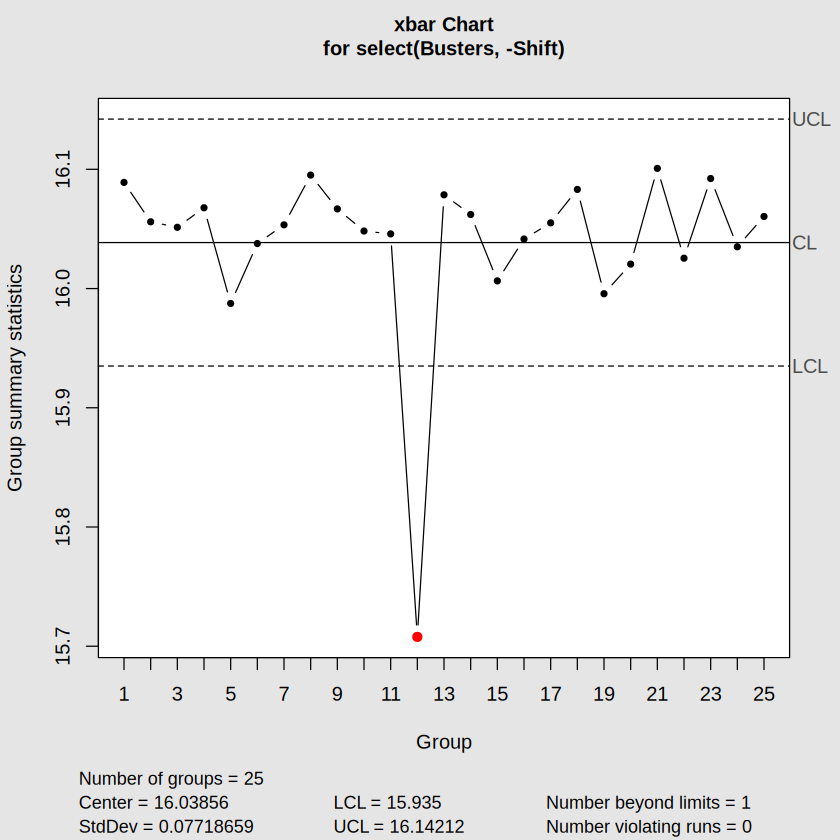

In [ ]:
## Q4 Code ##

## Clone your forked repository to Colab ##

## Specify your GitHub username:
user_name <- "NayshaM"

## Specify the repository:
repo_name <- "STAT-7110-Quality-Control"

## Set the web address to your forked repository:
repo_address <- paste0(
  "https://github.com/",
  user_name,
  "/",
  repo_name,
  ".git"
)

## Check to see if repo is already cloned to Colab, and if not, clone repo:
if (!dir.exists(repo_name)) {
  system(paste("git clone", repo_address))
} else {
  print("Repository already cloned to Colab.")
}

## Set working directory to /content/ where the repository was cloned
setwd("/content/STAT-7110-Quality-Control/Assignments/HW2")

## Install tidyverse, readxl, and qcc packages if necessary ##

install.packages(c("tidyverse", "readxl", "qcc"))

## Load the libraries ##

library(tidyverse)
library(readxl)
library(qcc)

# Read in the data

Busters <- read_xlsx("BustersSportsBar_PhaseI.xlsx")

Busters |>
  glimpse()

## Phase 1 X Chart ##

X_Chart <- qcc(Busters |> select(-`Shift`),
                   type = "xbar",
                   plot = TRUE)



# The process mean and standard deviation are 16.04 and .08, respectively.

### Q5: Construct a Phase I $R$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

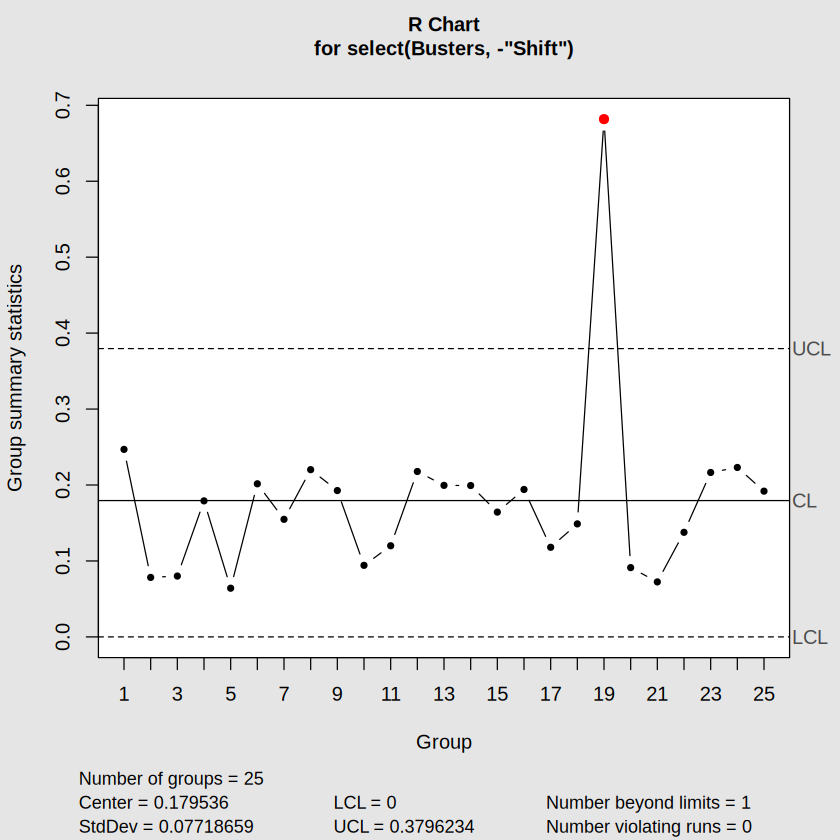

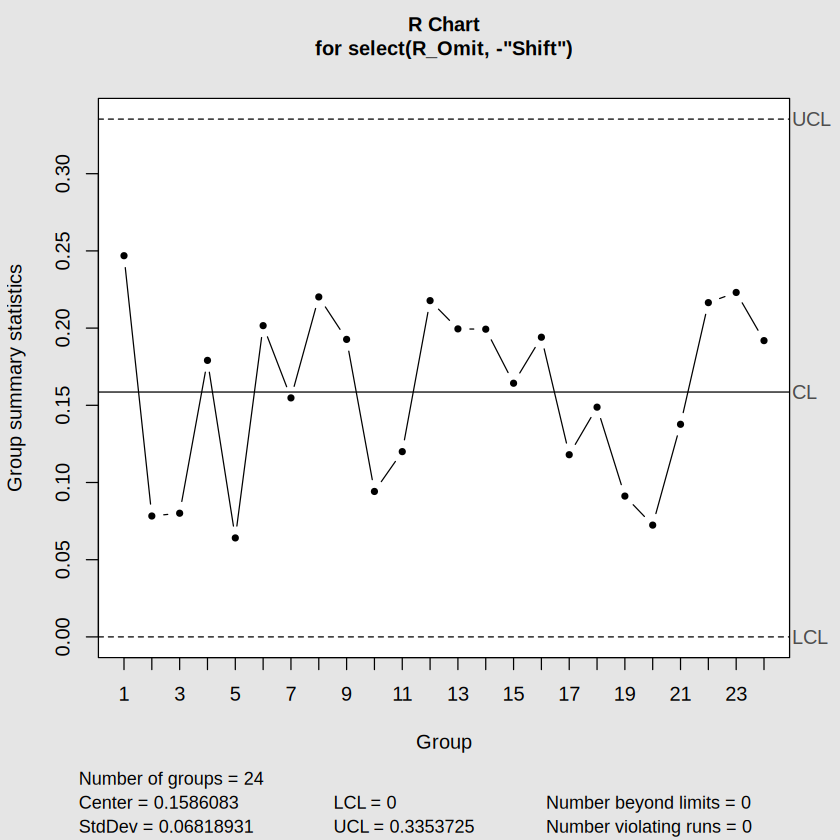

In [ ]:
## Q5 Code ##

R_Chart <- qcc(Busters |> select (-'Shift'),
                type = "R",
                plot = TRUE)

R_Omit <- Busters |>
  filter(Shift != 19)

R_Omit_Chart <- qcc(R_Omit |> select (-'Shift'),
                    type = "R",
                    plot = TRUE)

# The chart does not show evidence of statistical control because shift 19 is well above the upper control limit. This point may have been observed because the CO2 regulator could begin to wear out over the course of that shift causing irregularities in the pours.

### Q6: Using only the subgroups retained after Q5, construct the Phase I $\bar{X}$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

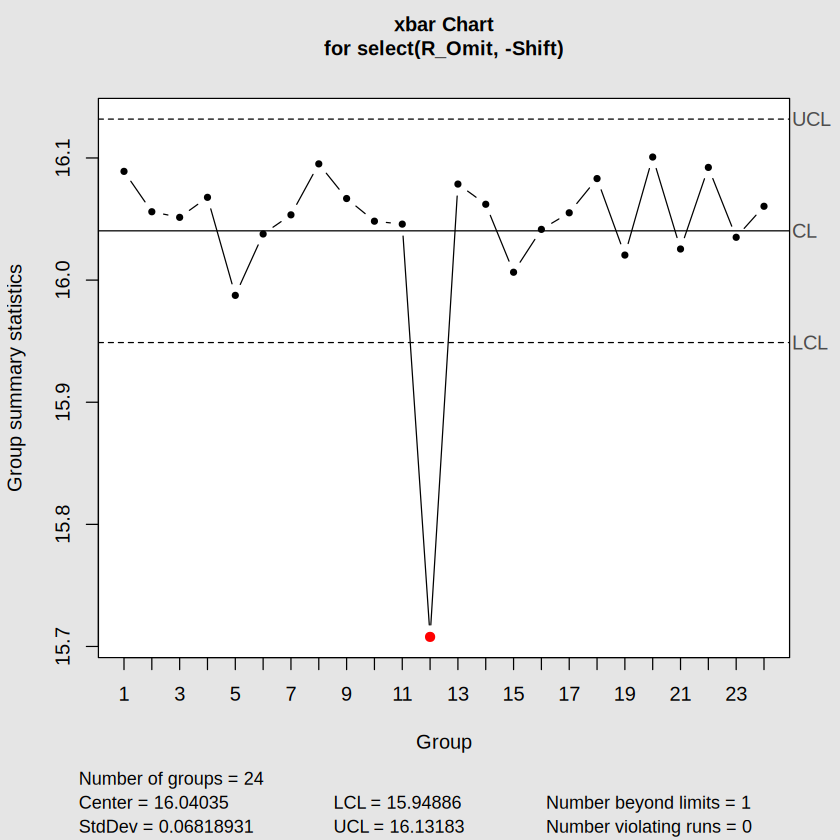

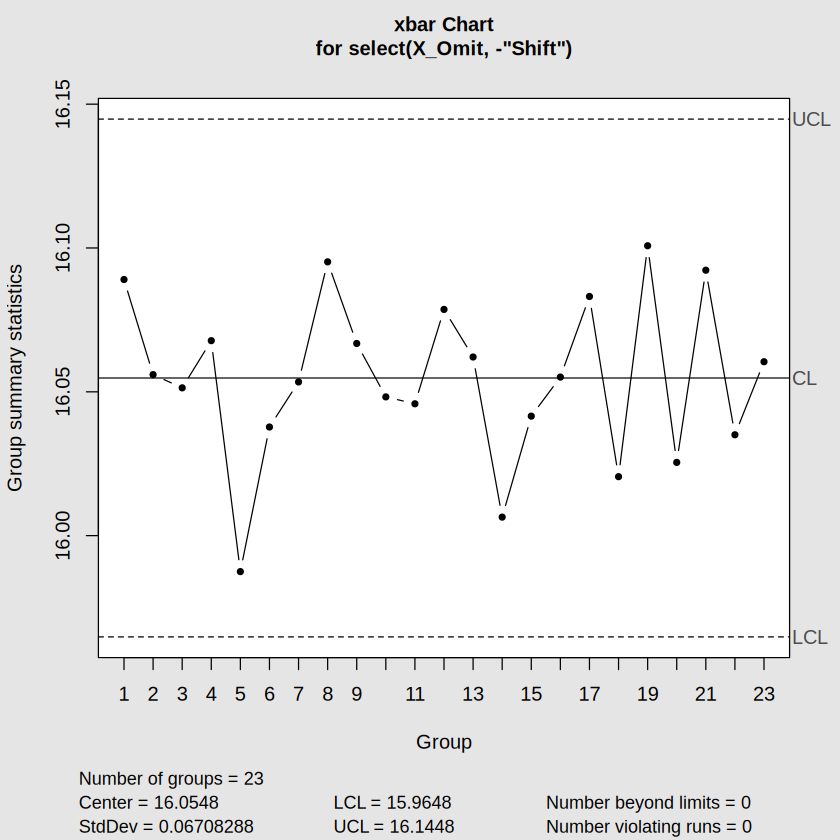

In [ ]:
## Q6 Code ##

X_Chart2 <- qcc(R_Omit |> select(-`Shift`),
                   type = "xbar",
                   plot = TRUE)

X_Omit <- R_Omit |>
  filter(Shift != 12)

X_Chart_Omit <- qcc(X_Omit |> select(-'Shift'),
                         type = "xbar",
                         plot = TRUE)

# The chart does not show evidence of statistical control because shift 12 is well below the lower control limit. This could be explained by an overdue C02 regulator that caused pours that were mostly foam.

### Q7: Using your final Phase I estimates of the process mean and process standard deviation, perform a process capability analysis against the specification limits given above. Report and interpret $FNC$, $C_p$, $C_{pk}$, and $C_{pm}$. Is the process capable of meeting specification? Is it well-centered?


Process Capability Analysis

Call:
process.capability(object = X_Chart_Omit, spec.limits = c(15.8,     16.2), target = 16, nsigmas = 3)

Number of obs = 115          Target = 16
       Center = 16.05           LSL = 15.8
       StdDev = 0.06708         USL = 16.2

Capability indices:

       Value    2.5%   97.5%
Cp    0.9938  0.8649  1.1225
Cp_l  1.2661  1.1190  1.4132
Cp_u  0.7215  0.6277  0.8152
Cp_k  0.7215  0.6098  0.8332
Cpm   0.7696  0.6521  0.8870

Exp<LSL 0%	 Obs<LSL 0%
Exp>USL 1.5%	 Obs>USL 2.6%


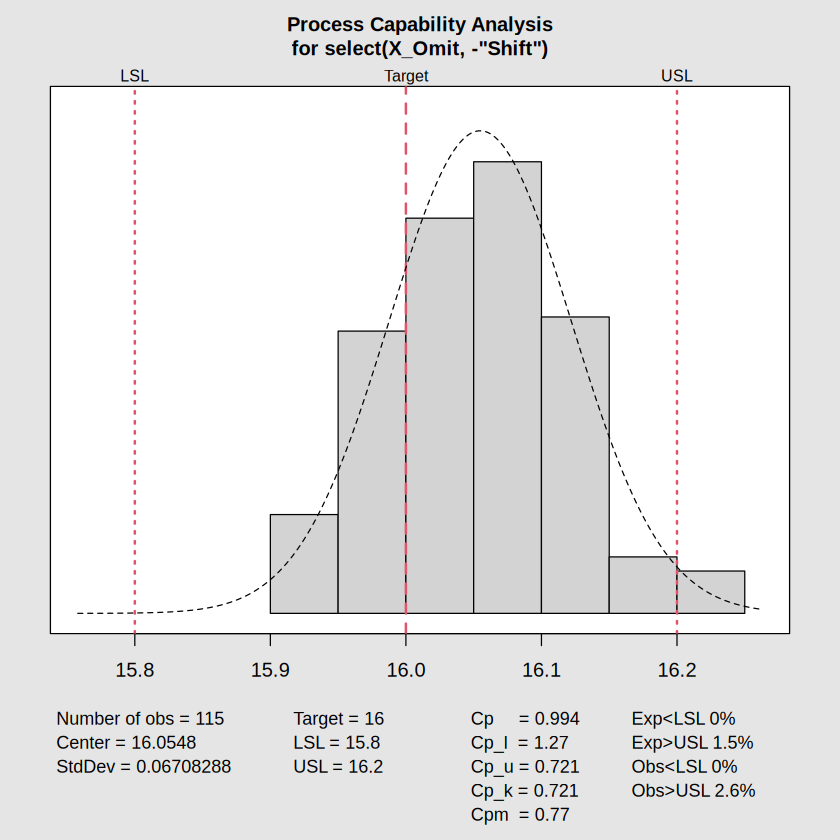

In [ ]:
## Q7 Code ##

process.capability(X_Chart_Omit,spec.limits=c(15.8,16.2),target=16,nsigmas=3)


# FNC
# The expected fraction nonconforming is about 1.5% (0% below the LSL + 1.5% above the USL). All of the expected nonconformance is on the upper (overpour) side. The observed fraction above the USL was 2.6%.
# CP
# Cp = 0.994, which means that the difference between USL & LSL is 0.994 times the difference between UCL & LCL. This is not good. A CP greater than 1 means there is a small process variation, and since this is less than 1, we can expect a greater process variation
# CPK
# From the chart, we can see that Cpk is 0.721, which is not good. This is below our CP meaning we don't see centered data and since it's less than 1 we see more variability.
# CPM
# CPM is 0.77, which is also not good because its < 1. This measure accounts for the process's centering.
# Since all measures are below 1, the process is not capable of meeting specifications and is not well-centered.

## Improve

### Q8: The general manager wants a monitoring scheme that reliably detects a sustained shift of about one process standard deviation (representing early-stage regulator drift) while keeping the in-control ARL around 370-500. Using the design guidance from lecture, select and briefly justify: (a) the CUSUM slack value $K$ and decision interval $H$, and (b) the EWMA smoothing constant $\lambda$ and width $L$, that you will carry forward into your Phase II monitoring plan.

# $K$ = 0.5, $H$ = 5. I chose this value for K because we want to keep it within 1 standard deviation and K = standard deviations / 2 which would be .5. I chose 5 for H because the rule of thumb: set $H = h\sigma$, where $h = 4$ or $5$ and h = 5 is the standard pairing with K = 0.5.

# For my EWMA smoothing constant I chose $\lambda$ = .10 and width $L$ = 2.814. I chose these values based on the chart where the pair provides the lowest ARL for a standard deviation of 1. This also keeps the in-control ARL at 500 per the 370-500 threshold.  

## Control

### Q9: Read the Phase II data into R. Using your final Phase I estimates from Q6 and the CUSUM parameters you selected in Q8, construct the Phase II CUSUM chart. Does the chart signal an out-of-control condition? If so, at which shift number?

List of 14
 $ call             : language cusum(data = Busters2, sizes = 5, center = mu0, std.dev = sigma0, decision.interval = h,      se.shift = k * 2, plot = T)
 $ type             : chr "cusum"
 $ data.name        : chr "Busters2"
 $ data             : num [1:20, 1:5] 16.1 16 16 16 16 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics       : Named num [1:20] 16.1 16 16 16 16.1 ...
  ..- attr(*, "names")= chr [1:20] "1" "2" "3" "4" ...
 $ sizes            : num [1:20] 5 5 5 5 5 5 5 5 5 5 ...
 $ center           : num 16.1
 $ std.dev          : num 0.0671
 $ pos              : num [1:20] 0.725 0 0 0 0.414 ...
 $ neg              : num [1:20] 0 -0.803 -0.91 -1.685 -0.271 ...
 $ head.start       : num 0
 $ decision.interval: num 5
 $ se.shift         : num 1
 $ violations       :List of 2
 - attr(*, "class")= chr "cusum.qcc"

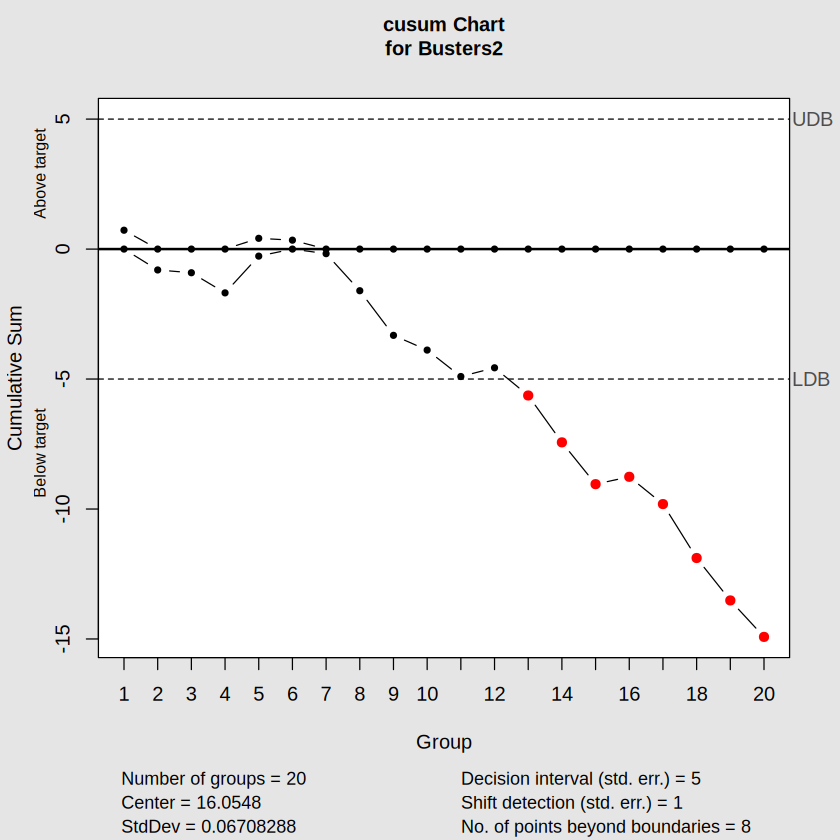

In [ ]:
## Q9 Code ##

# Phase 2 Data #

Busters2 <- read_xlsx("BustersSportsBar_PhaseII.xlsx")

Busters2 <- Busters2 |> select (-'Shift') |> as.data.frame()

# Phase 1 Estimates #

mu0 <- X_Chart_Omit$center
sigma0 <- X_Chart_Omit$std.dev

# Parameters #

k <-.5
h <- 5

cusum(Busters2,sizes=5,center=mu0, std.dev = sigma0, se.shift=k*2,
      decision.interval = h,plot=T)





# Yes, the chart signals an out-of-control condition starting at shift 13.

### Q10: Using your final Phase I estimates from Q6 and the EWMA parameters you selected in Q8, construct the Phase II EWMA chart. Does the chart signal an out-of-control condition? If so, at which shift number?

List of 15
 $ call      : language ewma(data = Busters2, sizes = 5, center = mu0, std.dev = sigma0, lambda = lambda,      nsigmas = nsigmas)
 $ type      : chr "ewma"
 $ data.name : chr "Busters2"
 $ data      : num [1:20, 1:5] 16.1 16 16 16 16 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:20] 16.1 16 16 16 16.1 ...
  ..- attr(*, "names")= chr [1:20] "1" "2" "3" "4" ...
 $ sizes     : num [1:20] 5 5 5 5 5 5 5 5 5 5 ...
 $ center    : num 16.1
 $ std.dev   : num 0.0671
 $ x         : int [1:20] 1 2 3 4 5 6 7 8 9 10 ...
 $ y         : Named num [1:20] 16.1 16.1 16.1 16 16.1 ...
  ..- attr(*, "names")= chr [1:20] "1" "2" "3" "4" ...
 $ sigma     : num [1:20] 0.003 0.00404 0.00471 0.00519 0.00555 ...
 $ lambda    : num 0.1
 $ nsigmas   : num 2.81
 $ limits    : num [1:20, 1:2] 16 16 16 16 16 ...
  ..- attr(*, "dimnames")=List of 2
 $ violations: Named int [1:9] 11 13 14 15 16 17 18 19 20
  ..- attr(*, "names")= chr [1:9] "11" "13" "14" "15" ...
 - attr(*, "class")= ch

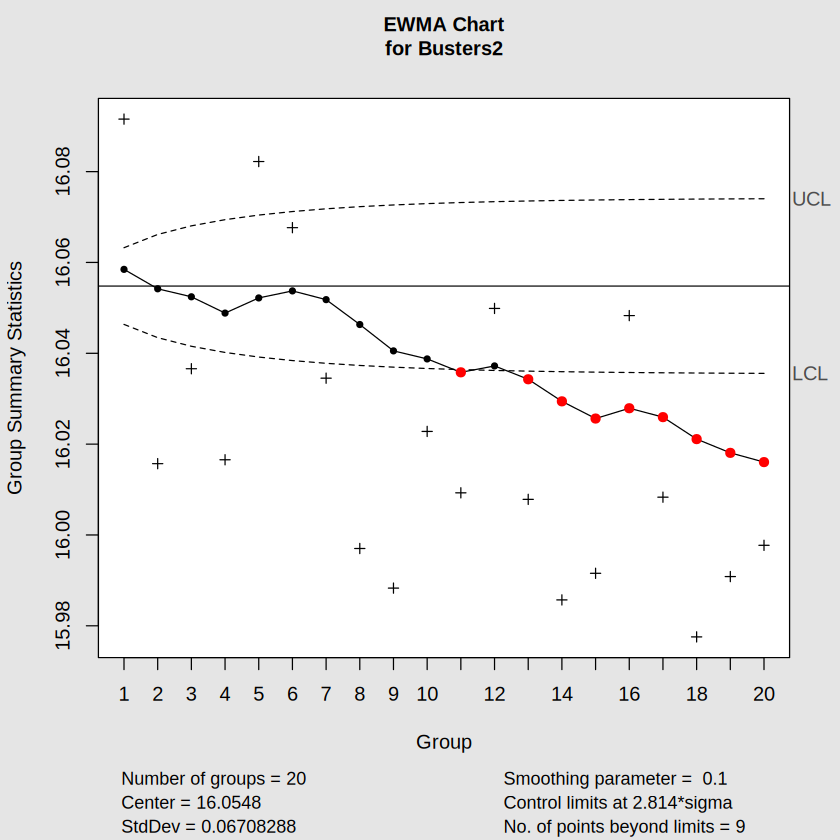

In [ ]:
## Q10 Code ##

# Phase 1 Estimates #

mu0 <- X_Chart_Omit$center
sigma0 <- X_Chart_Omit$std.dev


# Parameters #

lambda <- .10
nsigmas <- 2.814

ewma(Busters2, sizes = 5, center = mu0, std.dev = sigma0, lambda = lambda, nsigmas = nsigmas)

# Yes, this chart signals an out-of-control condition at shift 11, returning back to condition at shift 12, then going out-of-contol at shift 13 through 20.

### Q11: Compare the results of Q9 and Q10. Which chart detected the shift more quickly, if either? Is this consistent with what you would expect, given what you know about the relative sensitivity of CUSUM and EWMA charts to small, sustained shifts? Briefly explain.

In [ ]:
## Q11 Code ##

# The EWMA chart signaled first, at shift 11, while the CUSUM signaled at shift 13. This is consistent with expectations: CUSUM and EWMA charts both accumulate information over time and are far more sensitive to small, sustained shifts. Since the two designs were tuned to the same target, similar performance is expected. Either chart would give the GM an early warning of regulator drift.

### Q12: Provide an overview of the results that the general manager can provide to Buster's ownership. Does the CO2 regulator need to be replaced ahead of schedule, or can it run as planned?

# The regulator should not be left to run as planned. Both monitoring charts show that pours have been shrinking steadily for several shifts, and they are still trending down. The continued decrease in pour can lead to more customer complaints and bad reviews.